# **Conexión API BANXICO**

El objetivo del código es conectarse a la API de BANXICO para poder consultar y descargar series contenidas en el Catálogo de Series.

La consulta está diseñada solo para una serie ya que para el alcance del proyecto no se requiere mas, sin embargo, el código se puede modificar para obtener la consulta de mas de una serie al mismo tiempo.

Para la correcta ejecucción del código se requeire:
*   Generar token Banxico para consultar la API, https://www.banxico.org.mx/SieAPIRest/service/v1/token
*   Guardar token en Secretos con el nombre BANXICO_API_TOKEN


Instalación de la API de Banxico

In [ ]:
pip install Banxico-SIE

Código para conectarse a la API de Banxico y extraer la serie **SP74662 Inflación Subyacente Anual **, la extracción comprende de enero de 2000 al último índice publicado y guarda una versión csv para su consulta.



In [ ]:
from siebanxico import SIEBanxico
import requests
import pandas
import os

from google.colab import userdata
banxico_secret_token =userdata.get('BANXICO_API_TOKEN')

api_cliente =SIEBanxico(token=banxico_secret_token, locale="es")

series_id =  "SP74662"
start_date = "2000-01-01"
end_date = "2026-12-31"

df_monthly_inflation = api_cliente.getSeriesData(
    series_id,
    startDate=start_date,
    endDate=end_date
)

import os

series_name = df_monthly_inflation.columns[0][1]

df_cleaned_inflation = df_monthly_inflation.copy()
df_cleaned_inflation.columns = [series_name]

output_dir = 'output_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_csv_path = os.path.join(f"{output_dir}/{series_id}_{series_name}.csv")
df_cleaned_inflation.to_csv(output_csv_path, index=True)

print(f"{series_name} de Banxico ({start_date[:7]} a {end_date[:7]}):")
display(df_monthly_inflation.head())
display(df_monthly_inflation.tail())
print(f"data saved to '{output_csv_path}'")

Inflación Subyacente (nueva definición) Anual de Banxico (2000-01 a 2026-12):


,SP74662
,Inflación Subyacente (nueva definición) Anual
fecha,
2000-01-01,13.17
2000-02-01,12.36
2000-03-01,11.33
2000-04-01,10.59
2000-05-01,10.01


,SP74662
,Inflación Subyacente (nueva definición) Anual
fecha,
2025-10-01,4.28
2025-11-01,4.43
2025-12-01,4.33
2026-01-01,4.52
2026-02-01,4.50


data saved to 'output_data/SP74662_Inflación Subyacente (nueva definición) Anual.csv'


Con base a la extracción de la serie descargada de Banxico procedemos a pronosticar el comportamiento de nuestra serie para 2026.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the neural network...
Training complete.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Inflación proyectada para Enero 2026 a Diciembre 2026:


,Forecasted Inflation
fecha,
2026-01-01,4.410821
2026-02-01,4.443958


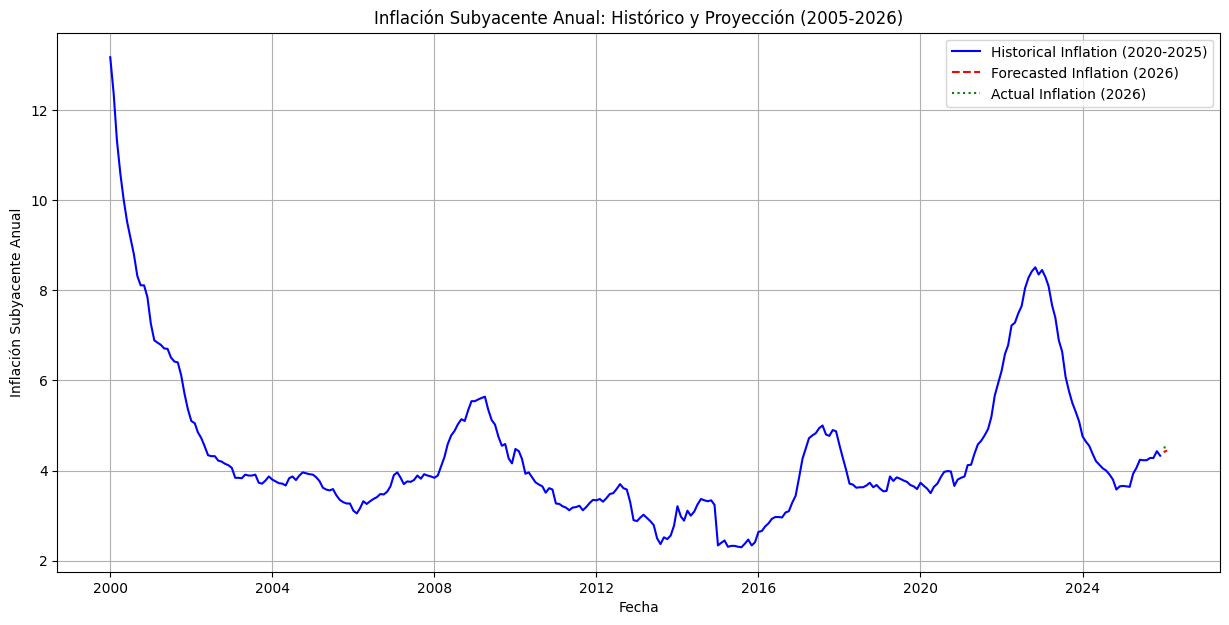

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Ensure df_cleaned_inflation is a DataFrame and sorted by index (date)
df_cleaned_inflation.index = pd.to_datetime(df_cleaned_inflation.index)
df_cleaned_inflation = df_cleaned_inflation.sort_index()

# Extract the series values
data = df_cleaned_inflation.values.astype('float32')

# Split into training and forecasting sets
# Train up to the end of 2025
train_end_date = '2025-12'
train_data = df_cleaned_inflation.loc[df_cleaned_inflation.index <= train_end_date]
forecast_data_actual = df_cleaned_inflation.loc[df_cleaned_inflation.index > train_end_date]

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler.fit_transform(train_data)

# Create a function to convert time series into supervised learning problem
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Define the look_back period (number of previous months to consider)
look_back = 12 # Using 12 months for yearly seasonality

# Create datasets for training
X_train, y_train = create_dataset(scaled_train_data, look_back)

# Build a simple MLP model
model = Sequential()
model.add(Dense(units=50, activation='relu', input_dim=look_back))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
print("Training the neural network...")
model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=0)
print("Training complete.")

# --- Forecasting for 2026 ---

# Get the last 'look_back' values from the scaled training data for initial prediction input
last_train_batch = scaled_train_data[len(scaled_train_data) - look_back:].reshape(1, look_back)

forecasted_scaled_2026 = []
num_forecast_steps = len(forecast_data_actual) # Forecast for all months in 2026

for i in range(num_forecast_steps):
    # Make prediction for the next month
    current_prediction = model.predict(last_train_batch)[0, 0]
    forecasted_scaled_2026.append(current_prediction)

    # Update the input batch for the next prediction (remove oldest, add newest forecast)
    last_train_batch = np.append(last_train_batch[:, 1:], [[current_prediction]], axis=1)

# Inverse transform the forecasted values
forecasted_2026 = scaler.inverse_transform(np.array(forecasted_scaled_2026).reshape(-1, 1))

# Create a DataFrame for the forecasted 2026 values
forecast_dates_2026 = forecast_data_actual.index
forecast_df_2026 = pd.DataFrame(forecasted_2026, index=forecast_dates_2026, columns=['Forecasted Inflation'])

# Display forecasted values for 2026
print("\nInflación proyectada para Enero 2026 a Diciembre 2026:")
display(forecast_df_2026)

# --- Visualization ---

# Prepare data for plotting
historical_data_for_plot = df_cleaned_inflation.loc[df_cleaned_inflation.index <= train_end_date]

plt.figure(figsize=(15, 7))
plt.plot(historical_data_for_plot.index, historical_data_for_plot.values, label='Historical Inflation (2020-2025)', color='blue')
plt.plot(forecast_df_2026.index, forecast_df_2026['Forecasted Inflation'], label='Forecasted Inflation (2026)', color='red', linestyle='--')
plt.plot(forecast_data_actual.index, forecast_data_actual.values, label='Actual Inflation (2026)', color='green', linestyle=':')

plt.title('Inflación Subyacente Anual: Histórico y Proyección (2005-2026)')
plt.xlabel('Fecha')
plt.ylabel('Inflación Subyacente Anual')
plt.legend()
plt.grid(True)
plt.show()


# **Entrenamiento de Redes Neuronales**

Transformación de los de datos extraidos de la API de Banxico:
*   Definición de Hiperparámetros
*   Limpieza y extración de datos.
*   Extración de información.
*   Normalización.
*   Creación de función que convierte las series de tiempo en un problema de aprendizaje supervisado.
*   Gráfico de datos históricos.
*   Transformación










In [ ]:
hidden_states = 50
windows = 12
batch_size = 32
epochs = 50
learning_rate = 0.001
seed = 1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_cleaned_inflation.index = pd.to_datetime(df_cleaned_inflation.index)
df_cleaned_inflation = df_cleaned_inflation.sort_index()

data = df_cleaned_inflation.values.astype('float32')
data = df_cleaned_inflation.values.astype('float32')

train_end_date = '2025-12'
train_data = df_cleaned_inflation.loc[df_cleaned_inflation.index <= train_end_date]
forecast_data_actual = df_cleaned_inflation.loc[df_cleaned_inflation.index > train_end_date]

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler.fit_transform(train_data)

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 12

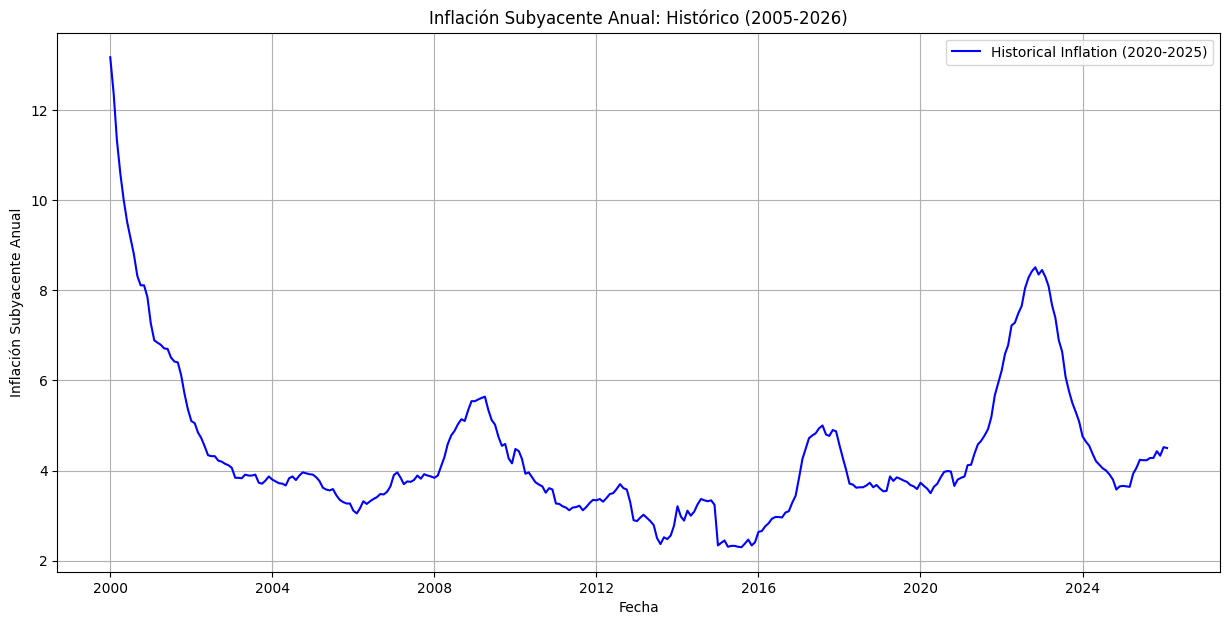

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df_cleaned_inflation.index, df_cleaned_inflation.iloc[:, 0], label='Historical Inflation (2020-2025)', color='blue')

plt.title('Inflación Subyacente Anual: Histórico (2005-2026)')
plt.xlabel('Fecha')
plt.ylabel('Inflación Subyacente Anual')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(data)
x_scaled.shape


(314, 1)

In [ ]:
scaler.fit(data)

MinMaxScaler()

In [ ]:
scaler.transform(data)

array([[9.99999940e-01],
       [9.25482929e-01],
       [8.30726802e-01],
       [7.62649477e-01],
       [7.09291637e-01],
       [6.64213479e-01],
       [6.32014692e-01],
       [5.97976089e-01],
       [5.53817809e-01],
       [5.34498572e-01],
       [5.34498572e-01],
       [5.10579586e-01],
       [4.56301749e-01],
       [4.22263086e-01],
       [4.17663276e-01],
       [4.13063467e-01],
       [4.05703783e-01],
       [4.04783785e-01],
       [3.87304544e-01],
       [3.79024863e-01],
       [3.77184927e-01],
       [3.51425946e-01],
       [3.12787473e-01],
       [2.81508744e-01],
       [2.57589698e-01],
       [2.52989888e-01],
       [2.34590605e-01],
       [2.22631082e-01],
       [2.06071749e-01],
       [1.87672511e-01],
       [1.85832575e-01],
       [1.85832575e-01],
       [1.76632926e-01],
       [1.74792990e-01],
       [1.70193210e-01],
       [1.67433307e-01],
       [1.61913529e-01],
       [1.41674325e-01],
       [1.41674325e-01],
       [1.40754357e-01],


Entrenamiento:

*   Creación del dataset
*   Datos de entrenamiento 80% = 251
*   Datos de prueba = 251 -12

In [ ]:
X_train, y_train = create_dataset(scaled_train_data, look_back)

In [ ]:
import numpy as np

window = 12
split = int(len(data) * 0.8)

x_train = data[:split]
x_test  = data[split - window:]

In [ ]:
x_train[:5]

array([[13.17],
       [12.36],
       [11.33],
       [10.59],
       [10.01]], dtype=float32)

In [ ]:
import tensorflow as tf

dataset_train = tf.keras.utils.timeseries_dataset_from_array(
    data=x_train[:-1],
    targets=x_train[window:],
    sequence_length=window,
    batch_size=batch_size,
    shuffle=False
)

dataset_test = tf.keras.utils.timeseries_dataset_from_array(
    data=x_test[:-1],
    targets=x_test[window:],
    sequence_length=window,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
for x, y in dataset_train:
    print(x.shape, y.shape)
    break

(32, 12, 1) (32, 1)


In [ ]:
print(dataset_train)

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None))>


Modelo

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
import tensorflow as tf

tf.random.set_seed(seed)
model = Sequential()
model.add(SimpleRNN(hidden_states, return_sequences=False, input_shape=(windows, 1)))
model.add(Dropout(0.5))
model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Optimizador, EarlyStopping, Callbacks y Compile

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

optimizer = Adam(learning_rate=learning_rate)
early_stopping_loss = EarlyStopping(monitor='loss', patience=5)
callbacks = [early_stopping_loss]
model.compile(loss='mean_squared_error', optimizer=optimizer)

Entrenamiento

In [ ]:
history = model.fit(
              dataset_train,
              epochs=epochs,
              batch_size=batch_size,
              verbose=True,
              callbacks=callbacks)
print("loss: ", history.history['loss'][-1])

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 5.1324
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.4694
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2677
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5512
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5188
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.3657
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2503
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.8977
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9451
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8627
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7148
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6633
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7033
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6361
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.5947
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━━━

/tmp/ipykernel_4823/1686999317.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


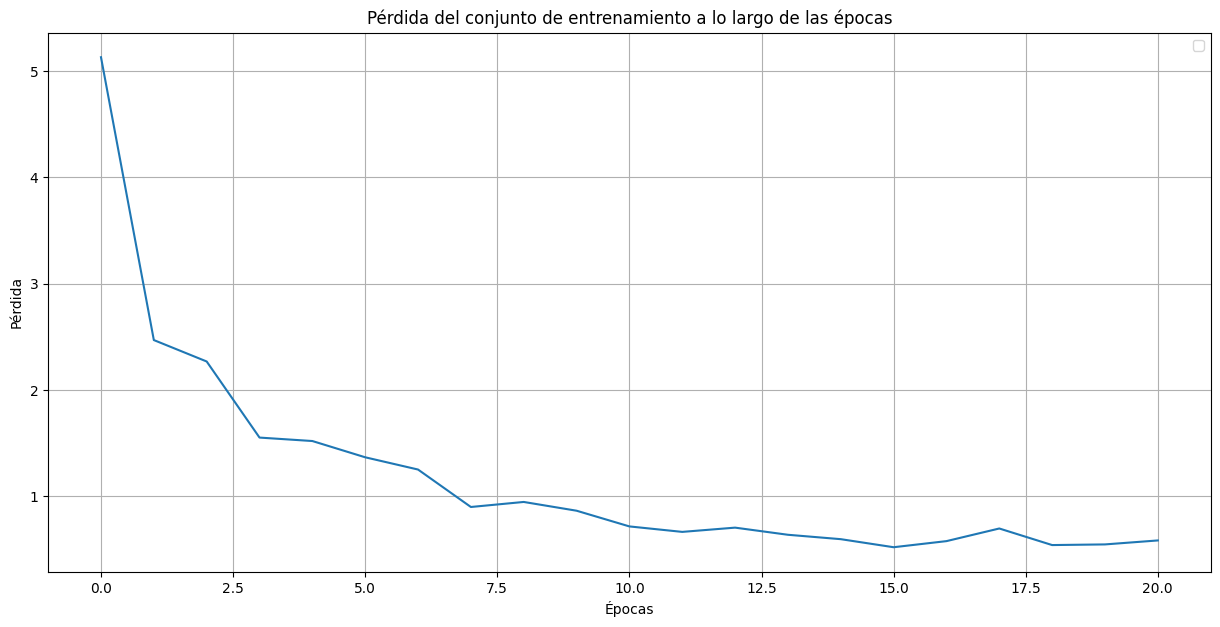

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(history.history['loss'])

plt.title('Pérdida del conjunto de entrenamiento a lo largo de las épocas')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def plot_predictions(model):

    y_hat_train = model.predict(dataset_train)
    y_hat_test = model.predict(dataset_test)

    y_hat_train_rescaled = scaler.inverse_transform(y_hat_train)
    y_hat_test_rescaled = scaler.inverse_transform(y_hat_test)

    train_pred_dates = df_cleaned_inflation.index[window:split]

    test_pred_dates = df_cleaned_inflation.index[split:]

    plt.figure(figsize=(15, 8))
    plt.title('Inflación Subyacente Anual: Histórico y Predicciones')

    plt.plot(df_cleaned_inflation.index, df_cleaned_inflation.values, label='Historical Inflation', color='blue')
    plt.plot(train_pred_dates, y_hat_train_rescaled.flatten(), label='Predict Train', color='green', linestyle='--')
    plt.plot(test_pred_dates, y_hat_test_rescaled.flatten(), label='Predict Test', color='red', linestyle='--')

    plt.ylabel('Inflación Subyacente Anual')
    plt.xlabel('Fecha')
    plt.grid(True)
    plt.legend()
    plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


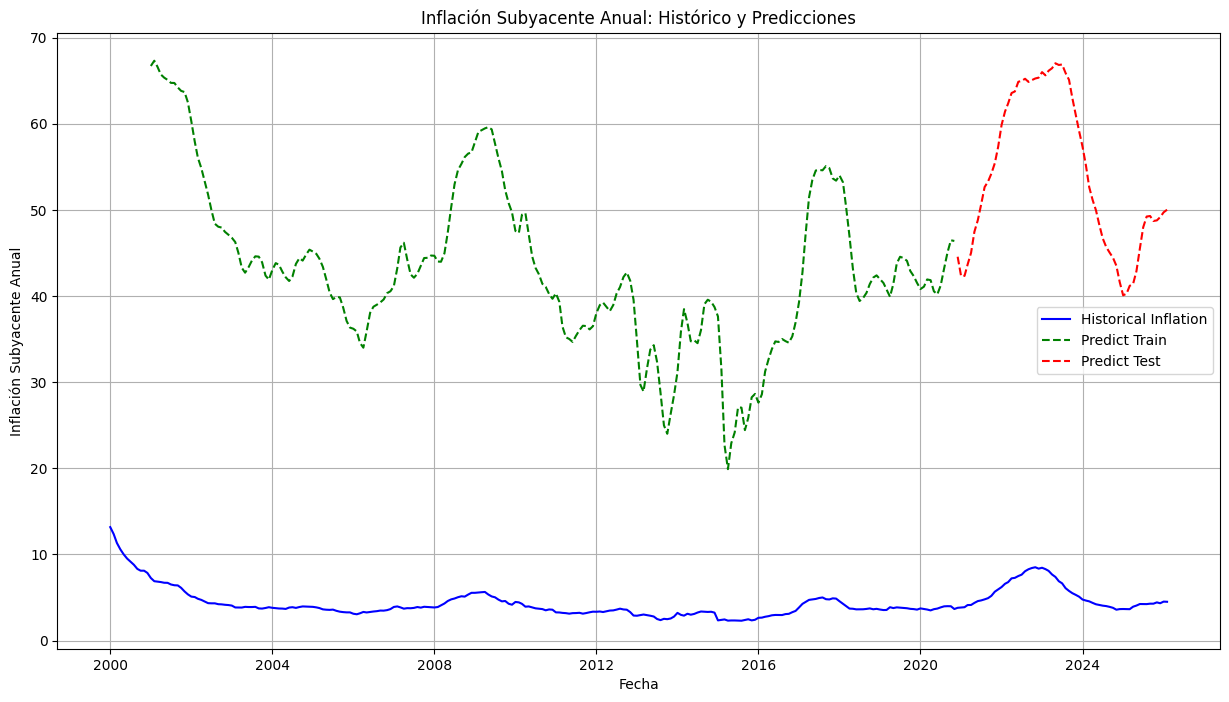

In [ ]:
plot_predictions(model)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
import tensorflow as tf

tf.random.set_seed(seed)

model = Sequential()

model.add(LSTM(hidden_states, return_sequences=False, input_shape=(windows, 1)))
model.add(Dropout(0.5))
model.add(Dense(1))
model.summary()
optimizer = Adam(learning_rate=learning_rate)
early_stopping_loss = EarlyStopping(monitor='loss', patience=5)
early_stopping_val_loss = EarlyStopping(monitor="val_loss", patience=5)
callbacks = [early_stopping_loss, early_stopping_val_loss]
model.compile(loss='mean_squared_error', optimizer=optimizer)

history = model.fit(
              dataset_train,
              epochs=epochs,
              batch_size=batch_size,
              verbose=True,)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 13.2032
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.2402 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 3.8588
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.9994
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6654
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.5413
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.3932
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 1.6229
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.2188
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.3447
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1652
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9910
Epoch 13/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.7594
Epoch 14/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8538
Epoch 15/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7202
Epoch 16/50
8/8 ━━━━━━━━━━━━━━━━

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


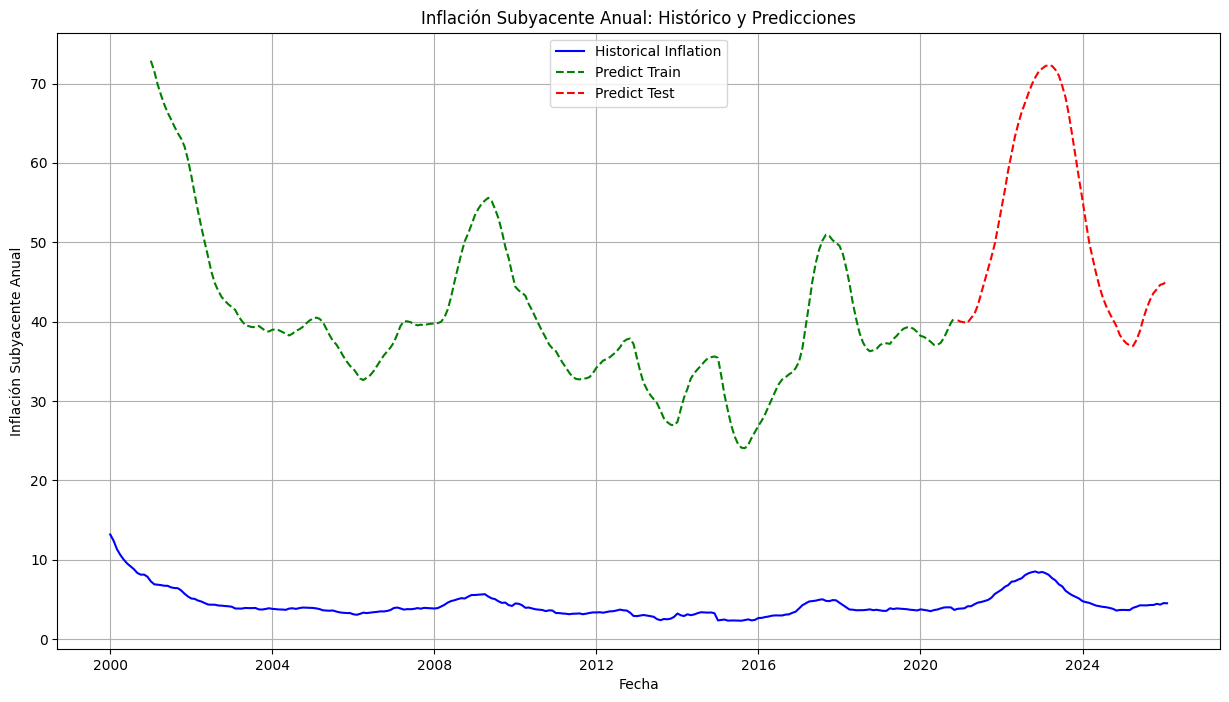

In [ ]:
plot_predictions(model)

In [ ]:
x_train.shape[0]

251

Model Cross Validation

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import TimeSeriesSplit

def train_sequence_model_cross_validation(model, epochs):

    tscv = TimeSeriesSplit(n_splits=2, test_size=13)

    val_loss = []
    train_loss = []
    cont = 1
    call_backs = {
        'val_loss': float('inf'),
        'loss': float('inf'),
    }
    val_loss_count = 0
    train_loss_count = 0

    epochs = 1
    for i in range(epochs):
        for i_2, (train_index, test_index) in enumerate(tscv.split(x_train)):
            dataset_train = tf.keras.utils.timeseries_dataset_from_array(
                            data=x_train[train_index][:-1],
                            targets=x_train[train_index][window:],
                            sequence_length=window,
                            batch_size=1,
                            shuffle=False
                        )
            dataset_validation = tf.keras.utils.timeseries_dataset_from_array(
                            data=x_train[test_index][:-1],
                            targets=x_train[test_index][window:],
                            sequence_length=window,
                            batch_size=1,
                            shuffle=False
                        )
            print(f"Epoch: {cont}/{epochs}")
            history = model.fit(
                    dataset_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    verbose=True,
                    validation_data = dataset_validation,)

            val_loss.append(history.history['val_loss'][-1])
            train_loss.append(history.history['loss'][-1])

            if call_backs['loss'] <= train_loss[-1]:
                train_loss_count += 1
                if val_loss_count == 5:
                    break
            else:
                train_loss_count = 0
                call_backs['loss'] = train_loss[-1]

            if call_backs['val_loss'] <= val_loss[-1]:
                val_loss_count += 1
            else:
                val_loss_count = 0
                call_backs['loss'] = train_loss[-1]

            if cont == (epochs+1):
                break
            cont += 1
        if val_loss_count==5 or train_loss_count==5:
            break
        if cont == (epochs+1):
            break
    return {'val_loss': val_loss, 'loss': train_loss}

In [ ]:
history = train_sequence_model_cross_validation(model, epochs=epochs)

Epoch: 1/1
213/213 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7133 - val_loss: 0.4400
Epoch: 2/1
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7976 - val_loss: 0.1472


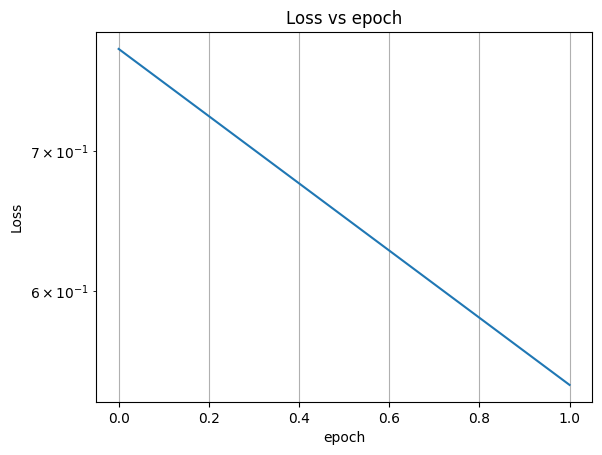

In [ ]:
plt.title("Loss vs epoch")
plt.yscale('log')
plt.ylabel("Loss")
plt.xlabel("epoch")
plt.plot(history['loss'])
plt.grid()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=2, test_size=13)

for i, (train_index, test_index) in enumerate(tscv.split(x_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224]
  Test:  index=[225 226 227 228 229 230 231 232 233 234 235 236

In [ ]:
model.get_weights()

[array([[ 2.27256998e-01,  9.80982110e-02, -1.13946810e-01,
          1.36978775e-01, -6.80670589e-02, -1.41879180e-02,
          9.21842754e-02, -1.51391983e-01,  9.02453586e-02,
          2.47757435e-02,  6.66287541e-02,  1.66412860e-01,
          1.92250639e-01, -7.64146969e-02,  4.87966835e-02,
         -1.17232718e-01,  1.58920109e-01, -2.79474631e-02,
         -2.14592181e-02, -1.08481944e-01,  2.12987870e-01,
          3.56281013e-03, -5.38780354e-03,  1.75169215e-01,
          2.03662768e-01, -1.26849972e-02,  3.60049605e-02,
          1.31360933e-01,  2.67530326e-02, -2.14404799e-02,
          9.48907286e-02,  8.06345120e-02, -5.97502515e-02,
          1.40519604e-01,  3.15086618e-02, -1.53370976e-01,
          1.65709317e-01,  1.96317583e-01,  7.92583674e-02,
          5.04965819e-02,  3.79245132e-02,  1.32318243e-01,
          1.69412479e-01,  1.22581579e-01,  1.95092931e-01,
          9.54719484e-02, -4.34117876e-02,  1.30518351e-03,
          2.02903971e-01, -2.15468761e-0

In [ ]:
import tensorflow as tf

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(look_back,)))
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(1))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,401 (5.47 KB)

 Trainable params: 1,401 (5.47 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)

In [ ]:
model.compile(loss=loss, optimizer=optimizer, metrics=[loss])

In [ ]:
history = model.fit(X_train,
                    y_train,
                    epochs=50,
                    batch_size=1,
                    verbose=2)

Epoch 1/50
300/300 - 1s - 4ms/step - loss: 0.0040 - mean_squared_error: 0.0040
Epoch 2/50
300/300 - 1s - 2ms/step - loss: 0.0014 - mean_squared_error: 0.0014
Epoch 3/50
300/300 - 1s - 2ms/step - loss: 0.0012 - mean_squared_error: 0.0012
Epoch 4/50
300/300 - 1s - 2ms/step - loss: 0.0011 - mean_squared_error: 0.0011
Epoch 5/50
300/300 - 1s - 2ms/step - loss: 9.9001e-04 - mean_squared_error: 9.9001e-04
Epoch 6/50
300/300 - 1s - 2ms/step - loss: 9.2713e-04 - mean_squared_error: 9.2713e-04
Epoch 7/50
300/300 - 1s - 3ms/step - loss: 8.6168e-04 - mean_squared_error: 8.6168e-04
Epoch 8/50
300/300 - 1s - 5ms/step - loss: 8.0958e-04 - mean_squared_error: 8.0958e-04
Epoch 9/50
300/300 - 1s - 3ms/step - loss: 7.6406e-04 - mean_squared_error: 7.6406e-04
Epoch 10/50
300/300 - 1s - 2ms/step - loss: 7.5183e-04 - mean_squared_error: 7.5183e-04
Epoch 11/50
300/300 - 1s - 2ms/step - loss: 7.1296e-04 - mean_squared_error: 7.1296e-04
Epoch 12/50
300/300 - 1s - 2ms/step - loss: 6.5382e-04 - mean_squared_err

In [ ]:
import plotly.express as px

losses = history.history['loss']
eje_x = np.arange(len(losses))

fig = px.line(
    x=eje_x,
    y=losses,
    title='Historia de entrenamiento',
    labels=dict(x='Épocas', y='Error')
)
fig.show()

In [ ]:
y_pred_model = model.predict(X_train)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [ ]:
import plotly.graph_objects as go

x_plot = train_data.index[look_back:]

y_actual_plot = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_pred_plot = scaler.inverse_transform(y_pred_model).flatten()


fig = go.Figure()
fig.add_trace(
    go.Scatter(x=x_plot, y=y_actual_plot, mode='markers', name='Datos crudos')
)
fig.add_trace(
    go.Scatter(x=x_plot, y=y_pred_plot, mode='lines', name='Modelo ajustado')
)

fig.show()

Forcasting Inflación 2026

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Inflación proyectada para Enero 2026 a Diciembre 2026:


,Forecasted Inflation
2026-01-01,4.196393
2026-02-01,4.069951
2026-03-01,3.905675
2026-04-01,3.699729
2026-05-01,3.470084
2026-06-01,3.241344
2026-07-01,3.018287
2026-08-01,2.791210
2026-09-01,2.580130
2026-10-01,2.372174


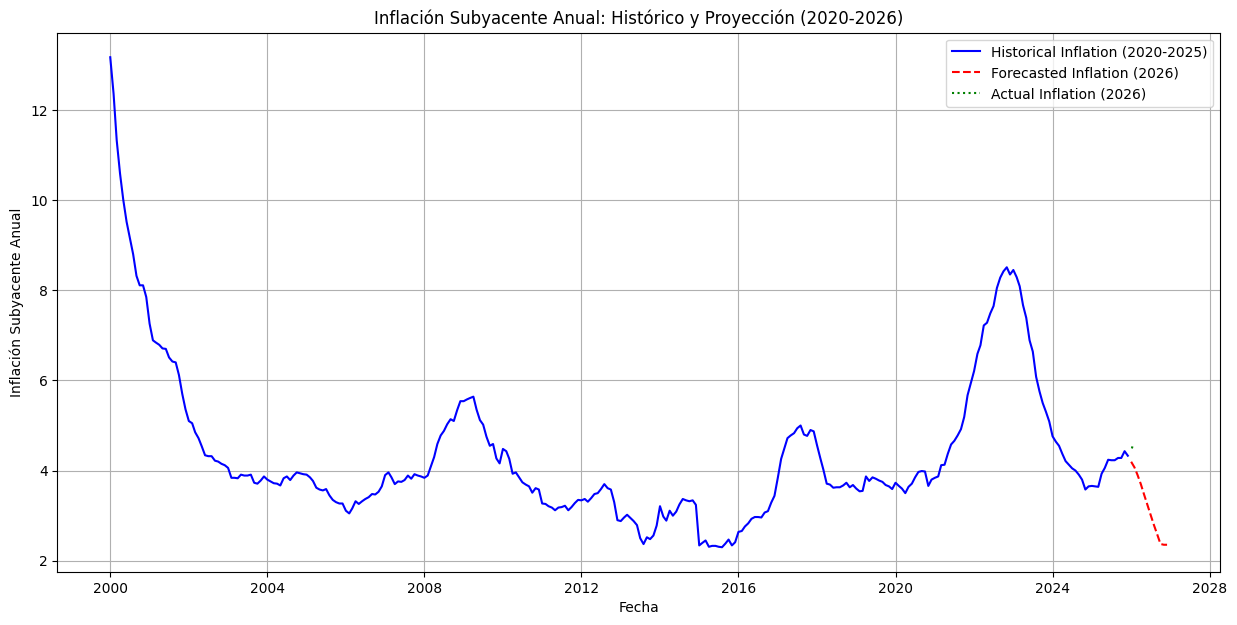

In [ ]:
last_train_batch = scaled_train_data[len(scaled_train_data) - look_back:].reshape(1, look_back)

forecasted_scaled_2026 = []
num_forecast_steps = 12

for i in range(num_forecast_steps):

    current_prediction = model.predict(last_train_batch)[0, 0]
    forecasted_scaled_2026.append(current_prediction)

    last_train_batch = np.append(last_train_batch[:, 1:], [[current_prediction]], axis=1)


forecasted_2026 = scaler.inverse_transform(np.array(forecasted_scaled_2026).reshape(-1, 1))


forecast_dates_2026 = pd.date_range(start='2026-01-01', periods=num_forecast_steps, freq='MS')
forecast_df_2026 = pd.DataFrame(forecasted_2026, index=forecast_dates_2026, columns=['Forecasted Inflation'])

print("\nInflación proyectada para Enero 2026 a Diciembre 2026:")
display(forecast_df_2026)

historical_data_for_plot = df_cleaned_inflation.loc[df_cleaned_inflation.index <= train_end_date]

plt.figure(figsize=(15, 7))
plt.plot(historical_data_for_plot.index, historical_data_for_plot.values, label='Historical Inflation (2020-2025)', color='blue')
plt.plot(forecast_df_2026.index, forecast_df_2026['Forecasted Inflation'], label='Forecasted Inflation (2026)', color='red', linestyle='--')
plt.plot(forecast_data_actual.index, forecast_data_actual.values, label='Actual Inflation (2026)', color='green', linestyle=':')

plt.title('Inflación Subyacente Anual: Histórico y Proyección (2020-2026)')
plt.xlabel('Fecha')
plt.ylabel('Inflación Subyacente Anual')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
display(forecast_df_2026)

,Forecasted Inflation
2026-01-01,4.196393
2026-02-01,4.069951
2026-03-01,3.905675
2026-04-01,3.699729
2026-05-01,3.470084
2026-06-01,3.241344
2026-07-01,3.018287
2026-08-01,2.791210
2026-09-01,2.580130
2026-10-01,2.372174


**# Pronóstico de Inflación 2026**

In [ ]:
annual_average_2026 = forecast_df_2026['Forecasted Inflation'].mean()
print(f"El promedio anual ponderado de la inflación proyectada para 2026 es: {annual_average_2026:.2f}%")

El promedio anual ponderado de la inflación proyectada para 2026 es: 3.17%
